In [3]:
import numpy as np
import pandas as pd
import os

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_dir = '/content/drive/MyDrive/Skin_Conditions'
dataset = image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

def split_dataset(dataset, train_size=0.8, val_size=0.1, test_size=0.1):
    total_size = len(dataset)
    train_end = int(total_size * train_size)
    val_end = train_end + int(total_size * val_size)

    train_dataset = dataset.take(train_end)
    val_dataset = dataset.skip(train_end).take(val_end - train_end)
    test_dataset = dataset.skip(val_end)

    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = split_dataset(dataset)

Found 2396 files belonging to 6 classes.


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

def augment_data(dataset):
    def augment(image, label):
        image = data_augmentation(image)
        return image, label

    return dataset.map(augment)

train_dataset = augment_data(train_dataset)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=32
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 334s 5s/step - accuracy: 0.4870 - loss: 1.3743 - val_accuracy: 0.8125 - val_loss: 0.6571
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 290s 5s/step - accuracy: 0.7198 - loss: 0.7821 - val_accuracy: 0.7812 - val_loss: 0.6349
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.7807 - loss: 0.6212 - val_accuracy: 0.8438 - val_loss: 0.4839
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.8062 - loss: 0.5464 - val_accuracy: 0.9107 - val_loss: 0.3494
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 294s 5s/step - accuracy: 0.8255 - loss: 0.4889 - val_accuracy: 0.9196 - val_loss: 0.3157
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 285s 5s/step - accuracy: 0.8573 - loss: 0.4302 - val_accuracy: 0.8571 - val_loss: 0.3986
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.8672 - loss: 0.3880 - val_accuracy: 0.8973 - val_loss: 0.3321
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 344s 5s/step - accuracy: 0.8714 - loss: 0.3642 - val_accuracy: 0.9018 - v

In [7]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.9127 - loss: 0.2295
Test Accuracy: 0.9127


In [8]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_fine_tune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=32
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - accuracy: 0.9286 - loss: 0.2253 - val_accuracy: 0.9062 - val_loss: 0.2446
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 364s 6s/step - accuracy: 0.9406 - loss: 0.1996 - val_accuracy: 0.9107 - val_loss: 0.2252
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 367s 6s/step - accuracy: 0.9526 - loss: 0.1670 - val_accuracy: 0.9330 - val_loss: 0.1707
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 365s 6s/step - accuracy: 0.9568 - loss: 0.1581 - val_accuracy: 0.9196 - val_loss: 0.2181
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 361s 6s/step - accuracy: 0.9500 - loss: 0.1464 - val_accuracy: 0.9375 - val_loss: 0.1957
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 362s 6s/step - accuracy: 0.9651 - loss: 0.1346 - val_accuracy: 0.9464 - val_loss: 0.1437
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 353s 6s/step - accuracy: 0.9641 - loss: 0.1311 - val_accuracy: 0.9598 - val_loss: 0.1553
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 360s 6s/step - accuracy: 0.9682 - loss: 0.1128 - val_accuracy: 0.9464 - v

In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9603 - loss: 0.1312
Test Accuracy: 0.9603


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


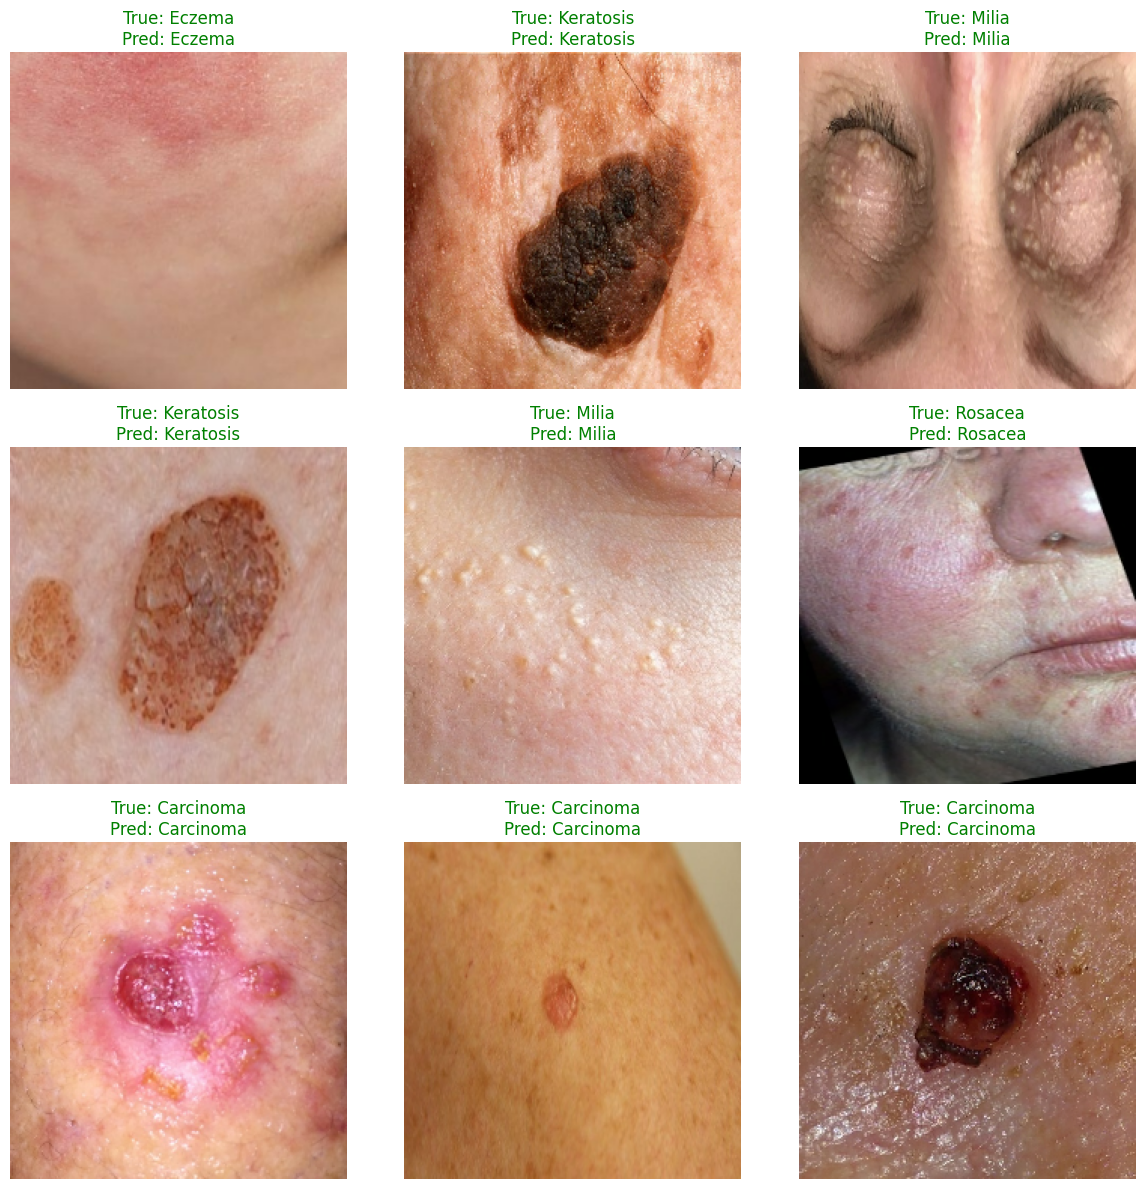

In [10]:
import matplotlib.pyplot as plt

class_names = [
    'Acne',
    'Carcinoma',
    'Eczema',
    'Keratosis',
    'Milia',
    'Rosacea'
]

def plot_random_images(test_dataset, model, class_names, num_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for image_batch, label_batch in test_dataset.take(1):
        predictions = model.predict(image_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        indices = np.random.choice(len(image_batch), num_images, replace=False)

        for idx, ax in enumerate(axes):
            img = image_batch[indices[idx]].numpy().astype(np.uint8)
            true_label = label_batch[indices[idx]].numpy()
            pred_label = predicted_labels[indices[idx]]

            ax.imshow(img)
            ax.axis('off')

            true_label_name = class_names[true_label]
            pred_label_name = class_names[pred_label]
            title_color = 'green' if true_label == pred_label else 'red'
            ax.set_title(f"True: {true_label_name}\nPred: {pred_label_name}", color=title_color, fontsize=12)

    plt.tight_layout()
    plt.show()

plot_random_images(test_dataset, model, class_names)

In [11]:
model.save("skin_model.keras")